## Example 6.7.1

$$
u'=\sin[(u+t)^2], \quad 0 \le t \le 4, \quad u(0)=-1 
$$ 

In [ ]:
using OrdinaryDiffEq
ivp = ODEProblem((u, p, t) -> sin((t + u)^2), -1.0, (0.0, 4.0))
u_ref = solve(ivp, reltol=1e-14, abstol=1e-14);

In [ ]:
using FNCFunctions, LinearAlgebra, PrettyTables
n = @. [round(Int, 4 * 10^k) for k in 0:0.5:3]
err = []
for n in n
    t, u = FNC.ab4(ivp, n)
    push!(err, norm(u_ref.(t) - u, Inf))
end
pretty_table((n=n, err=err); 
    column_labels=["n", "inf-norm error"], backend=:html)

In [ ]:
using Plots, LaTeXStrings
theme(:dark), default(thickness_scaling=1.4)

plot(n, err; m=3, label="AB4",  legend=:bottomleft,
    xaxis=(:log10, L"n"),  yaxis=(:log10, "inf-norm error"))

plot!(n, 0.1 * err[end] * (n / n[end]) .^ (-4), l=:dash, label=L"O(n^{-4})")

## Example 6.7.2

$$ u' = u^2 - u^3, \quad u(0) = 1/200 $$

In [20]:
using OrdinaryDiffEq
ivp = ODEProblem((u, p, t) -> u^2 - u^3, 0.005, (0, 400.0));

In [21]:
using FNCFunctions
tI, uI = FNC.am2(ivp, 200)

([0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0  …  382.0, 384.0, 386.0, 388.0, 390.0, 392.0, 394.0, 396.0, 398.0, 400.0], [0.005, 0.005050251230644515, 0.005101520199983277, 0.005153838089236625, 0.005207237364857105, 0.005261751845367025, 0.005317416772407103, 0.005374268886308781, 0.005432346506529583, 0.005491689617320263  …  1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0])

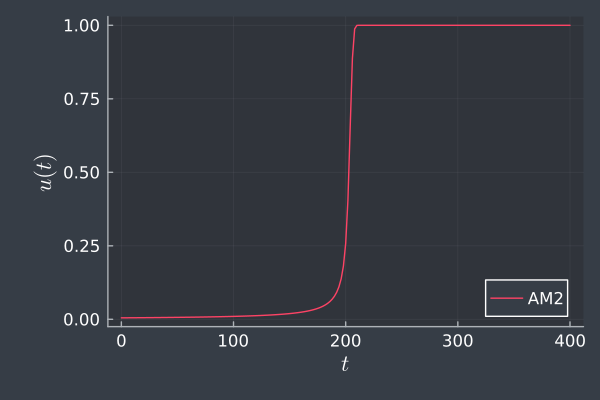

In [22]:
using Plots, LaTeXStrings
theme(:dark);  default(thickness_scaling=1.4)

plot(tI, uI; label="AM2", legend=:bottomright, xlabel=L"t",  ylabel=L"u(t)")

In [23]:
tE, uE = FNC.ab4(ivp, 200)

([0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0  …  382.0, 384.0, 386.0, 388.0, 390.0, 392.0, 394.0, 396.0, 398.0, 400.0], [0.005, 0.0050502487100199415, 0.005101515004349026, 0.0051538300546656495, 0.005207226294735842, 0.0052617375521755464, 0.005317399057836315, 0.005374247538750621, 0.005432321300880758, 0.005491660313909445  …  NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN])

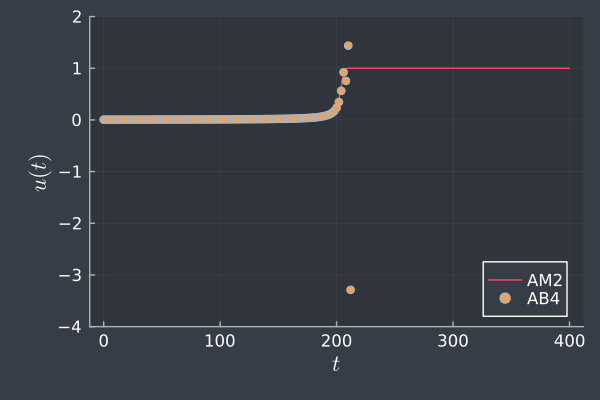

In [24]:
scatter!(tE, uE, m=3, label="AB4", ylim=[-4, 2])

In [25]:
uE[105:111]

7-element Vector{Float64}:
   0.7553857798343923
   1.4372970308402562
  -3.2889768512289934
 214.1791132643978
  -4.482089146771584e7
   4.1268902909420876e23
  -3.221441244795439e71

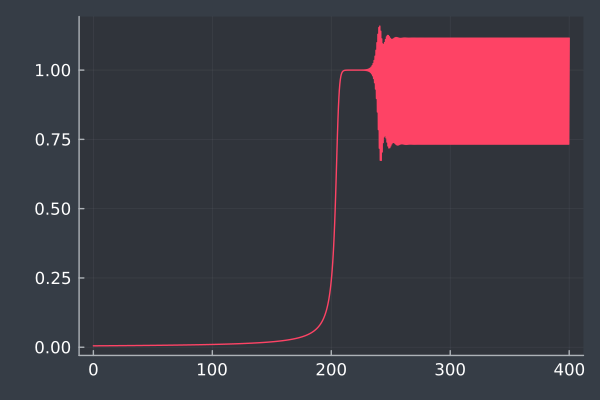

In [26]:
tE, uE = FNC.ab4(ivp, 1000)
plot(tE, uE; legend=false)

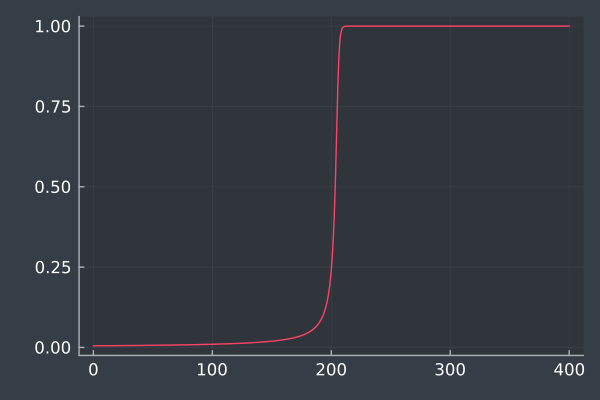

In [27]:
tE, uE = FNC.ab4(ivp, 1600)
plot(tE, uE; legend=false)